In [235]:
# Import Statements (General)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [236]:
# Import ML-Relevant Packages
from sklearn.ensemble import RandomForestClassifier, IsolationForest
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.tree import export_graphviz
from IPython.display import Image
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import seaborn as sns
from skopt import BayesSearchCV
import graphviz
import time

In [ ]:
# Import Data
p45_60_box = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_60_min_shock_box.csv")
p45_60_hc = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_60_min_shock_hc.csv")
p45_15_box = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_15_min_shock_box.csv")
p45_15_hc = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_15_min_shock_hc.csv")

In [238]:
# Define Feature Groups
binding = ['n_clusters_x', 'total_ReadCount', 'mean_ModeScore']
regions = ['frac_utr3','frac_intron']
all = ['n_clusters_x', 'total_ReadCount', 'mean_ModeScore', 'frac_utr3','frac_intron', 'frac_utr5', 'frac_cds']

In [239]:
# Hyperparameter Tuner
class HyperparameterTuning(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=1.5)
        self.threshold = threshold
    def fit(self, X, y = None):
        

SyntaxError: expected ':' (2858862072.py, line 3)

In [ ]:
# Outlier Remover
class IQROutlierDetection(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=1.5):
        self.threshold = threshold
    
    def fit(self, X, y=None):
        # Calculate IQR for each column
        self.iqr_ = np.percentile(X, 75, axis=0) - np.percentile(X, 25, axis=0)
        self.lower_bound_ = np.percentile(X, 25, axis=0) - self.threshold * self.iqr_
        self.upper_bound_ = np.percentile(X, 75, axis=0) + self.threshold * self.iqr_
        return self
    
    def transform(self, X):
        # Replace outliers with NaN (anything outside the IQR bounds)
        X_transformed = X.copy()
        for i in range(X.shape[1]):
            outlier_mask = (X[:, i] < self.lower_bound_[i]) | (X[:, i] > self.upper_bound_[i])
            X_transformed[outlier_mask, i] = np.nan
        return X_transformed
    

In [244]:
# Pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()), # TODO: Why MinMaxScaler()?
    ('outlier_remover', IQROutlierDetection()),
    ('imputer', KNNImputer()),
    ('classifier', RandomForestClassifier(max_depth=20, 
                                        min_samples_split=5, 
                                        min_samples_leaf=2,
                                        n_estimators=254, 
                                        random_state=42,
                                        bootstrap=False,
                                        criterion='log_loss',
                                        class_weight='balanced_subsample',
                                        max_features=None,
                                        min_impurity_decrease=69.3654976755853))
])


# Isolation forests require training per fold.
# Also, hyperparameter tune per cv.
# Cloning - or else the model will keep a copy of the tests. Instead of cloning the model, you clone the hyperparameters shallow copy. Shallow vs. Deep copy.
# Start with XGBoost.
# Robert thinks the first issue I'll have is with isolation.

In [ ]:
# Hyperparameters
param_dist = {
  'n_estimators': [100, 413],
  'max_depth': [None, 10, 20],
  'min_samples_split': [2,5],
  'min_samples_leaf': [1,2],
  'bootstrap': [True, False],
  'max_features': ['sqrt', 'log2', None],
  'criterion' : ['gini', 'entropy', 'log_loss'],
  'min_impurity_decrease' : [0.0,100],
  'class_weight' : ['balanced_subsample','balanced', None]
}

In [242]:
# Hyperparameter Tuning (BayesSearchCV)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

search = BayesSearchCV(rf, param_dist, n_iter = 30, cv = 5, scoring = 'f1',
                       refit = False, verbose = 1)

search.fit(X_train, y_train)

print('Best hyperparameters:',  search.best_params_)
print('Best Estimater:', search.best_estimator_)
print('Best grid hyperparameters:',  search.best_params_)
print('Best grid Estimater:',search.best_estimator_)

/opt/anaconda3/envs/codingpractice/lib/python3.13/site-packages/skopt/space/space.py:116: UserWarning: Dimension [100, 413] was inferred to Integer(low=100, high=413, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(100, 413), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/opt/anaconda3/envs/codingpractice/lib/python3.13/site-packages/skopt/space/space.py:116: UserWarning: Dimension [2, 5] was inferred to Integer(low=2, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(2, 5), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/opt/anaconda3/envs/codingpractice/lib/python3.13/site-packages/skopt/space/space.py:116: UserWarning: Dimension [1, 2] was inferred to Integer(low=1, high=2, prior='uniform', transform='i

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

AttributeError: 'BayesSearchCV' object has no attribute 'best_estimator_'

In [241]:
# Hyperparameter Tuning (GridSearchCV)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
  rf, param_grid=param_dist,
  cv=5, scoring='accuracy',
  n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best hyperparameters:',  grid_search.best_params_)
print('Best Estimater:', grid_search.best_estimator_)
print('Best grid hyperparameters:',  grid_search.best_params_)
print('Best grid Estimater:',grid_search.best_estimator_)

KeyboardInterrupt: 

In [ ]:
# # Preprocessor
# preprocessor = ColumnTransformer([
#     ('num', pipeline, all)
# ])

In [ ]:
# # Final Pipeline
# pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', RandomForestClassifier(max_depth=10, 
#                                         min_samples_split=2, 
#                                         min_samples_leaf=5,
#                                         n_estimators=100, 
#                                         random_state=42,
#                                         bootstrap=True))
# ])

In [ ]:
# K Folds
n_splits = 10
skf = KFold(n_splits=n_splits, random_state = 42, shuffle=True)
X_array = p45_60_box[all].to_numpy()
y = p45_60_box['Expression']
data_splits_objects = skf.split(X_array,y)

In [245]:
# empty lists to capture the pred and exp
predicted_y = []
expected_y = []
fprs = []
tprs = []

# Fit iteratively
count = 0
for train_index, test_index in skf.split(X_array, y):
    
    count +=1

    X_train, X_test, y_train, y_test = train_test_split(X_array, y, test_size=0.2, stratify=y)
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    X_train = pd.DataFrame(X_train)
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    predicted_y.extend(y_pred)
    expected_y.extend(y_test)
    accuracy = accuracy_score(y_test, y_pred) 
    conf_m = confusion_matrix(y_test, y_pred)

    print("---------------------------------------------")
    print(f"Summary for validation {count}/{n_splits}:")
    #Display the accuracy
    print(f'Accuracy: {accuracy:.2f}')
    # Get ROC Metric
    y_pred_prob = classifier.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test,  y_pred_prob)
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f'AUC: {auc}')
    fprs.append(fpr)
    tprs.append(tpr)


---------------------------------------------
Summary for validation 1/10:
Accuracy: 0.19
AUC: 0.6236830271103688
---------------------------------------------
Summary for validation 2/10:
Accuracy: 0.19
AUC: 0.6798471026596429
---------------------------------------------
Summary for validation 3/10:
Accuracy: 0.19
AUC: 0.6539412822818965
---------------------------------------------
Summary for validation 4/10:
Accuracy: 0.19
AUC: 0.7648560966208403
---------------------------------------------
Summary for validation 5/10:
Accuracy: 0.19
AUC: 0.6453006552743158
---------------------------------------------
Summary for validation 6/10:
Accuracy: 0.19
AUC: 0.6251606064499551
---------------------------------------------
Summary for validation 7/10:
Accuracy: 0.19
AUC: 0.609260567904407
---------------------------------------------
Summary for validation 8/10:
Accuracy: 0.19
AUC: 0.699906848259026
---------------------------------------------
Summary for validation 9/10:
Accuracy: 0.19


Total k-fold accuracy = 80.60267857142858%


/var/folders/4y/9yl3btzn7r7b7xfvfw2_74t80000gn/T/ipykernel_4518/1373233743.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=4)


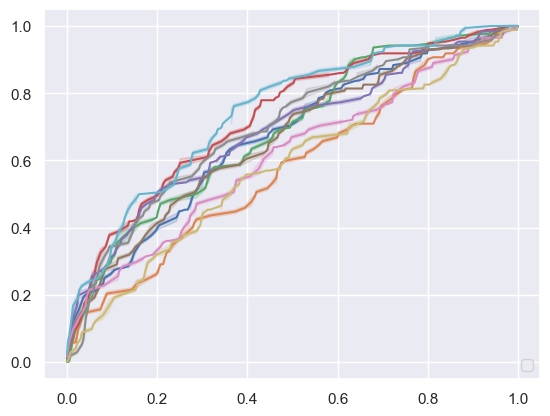

In [ ]:
# Plot Data
accuracy = accuracy_score(expected_y,predicted_y)
print(f"Total k-fold accuracy = {accuracy * 100}%")
param_dist = {
  'n_estimators': 100,
  'max_depth': 10,
  'min_samples_split': 5,
  'min_samples_leaf': 2
}
data_res = [fprs,tprs]
# plt.figure()
sns.set_theme(style="darkgrid")
for i in range(len(fprs)):
    sns.lineplot(data=pd.DataFrame(fprs[i],tprs[i]), x=fprs[i],y=tprs[i])
    # sns.title(f'Reciever Operator Characteristics (ROC): AUC = {auc}')
    # plt.xlabel('False Positive Rate (FPR)')
    # plt.ylabel('True Positive Rate (FPR)')
    # sns.plot([0,1], ls='--')
plt.legend(loc=4)
plt.show()

/var/folders/4y/9yl3btzn7r7b7xfvfw2_74t80000gn/T/ipykernel_4518/2135331946.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


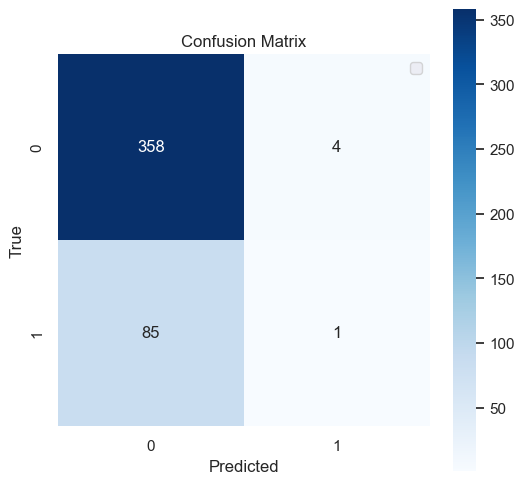

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_m, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.legend()
plt.show()

In [ ]:
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV
from scipy.stats import randint

param_dist = {
  'n_estimators': [100, 413],
  'max_depth': [None, 10, 20],
  'min_samples_split': [2,5],
  'min_samples_leaf': [1,2],
  'bootstrap': [True, False]
}


# Create a random forest classifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Finding with grid search
grid_search = GridSearchCV(
  rf, param_grid=param_dist,
  cv=5, scoring='accuracy',
  n_jobs=-1
)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
  rf, param_distributions=param_dist,
  n_iter=10, cv=5, scoring='accuracy',
  n_jobs=-1, random_state=42
)

rand_search.fit(X_train, y_train)
grid_search.fit(X_train,y_train)

best_score = rand_search.best_score_

print('Best hyperparameters:',  rand_search.best_params_)
print('Best Estimater:',rand_search.best_estimator_)
print('Best grid hyperparameters:',  grid_search.best_params_)
print('Best grid Estimater:',grid_search.best_estimator_)

Best hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': True}
Best Estimater: RandomForestClassifier(max_depth=10, min_samples_leaf=2, n_jobs=-1,
                       random_state=42)
Best grid hyperparameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best grid Estimater: RandomForestClassifier(max_depth=10, min_samples_leaf=2, n_jobs=-1,
                       random_state=42)
